In [1]:
import os
from processing.ecc import ECCSONDE, calculate_total_column_ozone
%matplotlib widget

# Create an instance of the ECCSONDE class
sonde = ECCSONDE()

In [ ]:
# choose a file
file = 'tests/data/ecc_asap/20220504C37105.TXT'

# Use the extract_ecc_asap method to process the file
result = sonde.extract_ecc_asap(file=file)

# Plot the result
sonde.plot_ecc_asap(result, suptitle=file)

In [ ]:
folder_path = '/product_data/data/pay/Kenya/NRB/OZONE_ECC_ASAP/incoming/'

for year in range(2019, 2025):
    year = str(year)
    # Compile data and metadata from the specified folder
    compiled_data = sonde.compile_ecc_asap(folder_path=os.path.join(folder_path, year))

    # Access the compiled metadata and data
    metadata_df = compiled_data['metadata']
    metadata_df.write_parquet(f'data/level1/ecc_asap_metadata_{year}.parquet')
    data_df = compiled_data['data']
    data_df.write_parquet(f'data/level1/ecc_asap_data_{year}.parquet')

In [ ]:
import polars as pl
for year in range(2019, 2025):
    year = str(year)
    data_df = pl.read_parquet(f'data/level1/ecc/ecc_asap_data_{year}.parquet')

    # Plot the compiled data interactively
    path = os.path.join('results/ecc/', year)
    os.makedirs(path, exist_ok=True)

    sonde.plot_compiled_ecc_asap(data_df=data_df, suptitle=f'ECC ASAP {year}', interactive=False, path=path)

In [ ]:
from processing.ecc import download_and_extract_shadoz_zip

for year in range(1998, 2023):
    df_data, df_metadata = download_and_extract_shadoz_zip(year=year)

In [10]:
import polars as pl

df_year = pl.read_parquet('data/level1/shadoz/ecc_sonde_data_2020.parquet')

# launch dates
dtm_launches = df_year.select(pl.col('dtm')).unique().to_series().to_list()

df_ecc = df_year.filter(pl.col('dtm')==dtm_launches[0])

df_ecc['filename'][0]

df_metadata_year = pl.read_parquet('data/level1/shadoz/ecc_sonde_metadata_2020.parquet')
df_metadata_year

source,NASA/GSFC/SHADOZ Archive,SHADOZ Principal Investigator,SHADOZ Archive Curator,SHADOZ Version,Reprocessed,SHADOZ format data created,STATION,Station Principal Investigator(s),Latitude (deg),Longitude (deg),Elevation (m),Launch Date,Launch Time (UT),Burst Pressure (hPa),Integrated O3 to end of data (DU),Radiosonde,Radiosonde Serial Number,Geom. Press. Offset Correction,Pressure sensor offset (hPa),Ozonesonde Instrument,KI Solution,Cathode Soln Volume (cc),Cathode Soln Volume Correction,Pump flowrate (sec/100ml),Flowrate Correction (%),Pump Temperature Correction,Applied background current (uA),Applied pump efficiency factors,Transfer Function,Missing or bad values,Comment_1,filename,variables,units
str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,list[str],list[str]
"""nairobi_202001…","""https://tropo.…","""Ryan M. Stauff…","""Debra E Kollon…","""06""","""Yes""","""Fri Oct 14 14:…","""Nairobi, Kenya…","""Christian Feli…","""-1.30""","""36.76""","""1795.00""","""20200108""","""07:18:38""","""6.25""","""198.65""","""Vaisala RS92""","""N1313323""","""No""","""0.000""","""1Z33250""","""0.5% Half Buff…","""3.0""","""No""","""29.500""","""9000""","""Yes""","""0.050""","""Komhyr et al.,…","""No""","""9000""","""Reprocessing r…","""nairobi_202001…","[""Time"", ""Press"", … ""GPS_Alt""]","[""sec"", ""hPa"", … ""km""]"
"""nairobi_202001…","""https://tropo.…","""Ryan M. Stauff…","""Debra E Kollon…","""06""","""Yes""","""Fri Oct 14 14:…","""Nairobi, Kenya…","""Christian Feli…","""-1.30""","""36.76""","""1795.00""","""20200115""","""07:41:05""","""6.95""","""203.76""","""Vaisala RS92""","""N2643160""","""Yes""","""0.000""","""1Z33320""","""0.5% Half Buff…","""3.0""","""No""","""29.700""","""9000""","""Yes""","""0.050""","""Komhyr et al.,…","""No""","""9000""","""Reprocessing r…","""nairobi_202001…","[""Time"", ""Press"", … ""GPS_Alt""]","[""sec"", ""hPa"", … ""km""]"
"""nairobi_202001…","""https://tropo.…","""Ryan M. Stauff…","""Debra E Kollon…","""06""","""Yes""","""Fri Oct 14 14:…","""Nairobi, Kenya…","""Christian Feli…","""-1.30""","""36.76""","""1795.00""","""20200122""","""07:13:53""","""5.88""","""207.09""","""Vaisala RS92""","""N2513318""","""Yes""","""0.000""","""1Z33321""","""0.5% Half Buff…","""3.0""","""No""","""30.100""","""9000""","""Yes""","""0.050""","""Komhyr et al.,…","""No""","""9000""","""Reprocessing r…","""nairobi_202001…","[""Time"", ""Press"", … ""GPS_Alt""]","[""sec"", ""hPa"", … ""km""]"
"""nairobi_202001…","""https://tropo.…","""Ryan M. Stauff…","""Debra E Kollon…","""06""","""Yes""","""Fri Oct 14 14:…","""Nairobi, Kenya…","""Christian Feli…","""-1.30""","""36.76""","""1795.00""","""20200129""","""07:41:18""","""7.31""","""188.91""","""Vaisala RS92""","""N2633312""","""No""","""0.000""","""1Z33248""","""0.5% Half Buff…","""3.0""","""No""","""29.900""","""9000""","""Yes""","""0.050""","""Komhyr et al.,…","""No""","""9000""","""Reprocessing r…","""nairobi_202001…","[""Time"", ""Press"", … ""GPS_Alt""]","[""sec"", ""hPa"", … ""km""]"
"""nairobi_202002…","""https://tropo.…","""Ryan M. Stauff…","""Debra E Kollon…","""06""","""Yes""","""Fri Oct 14 14:…","""Nairobi, Kenya…","""Christian Feli…","""-1.30""","""36.76""","""1795.00""","""20200212""","""08:56:48""","""6.95""","""208.03""","""Vaisala RS92""","""N2643184""","""No""","""0.000""","""1Z33322""","""0.5% Half Buff…","""3.0""","""No""","""30.000""","""9000""","""Yes""","""0.050""","""Komhyr et al.,…","""No""","""9000""","""Reprocessing r…","""nairobi_202002…","[""Time"", ""Press"", … ""GPS_Alt""]","[""sec"", ""hPa"", … ""km""]"
"""nairobi_202002…","""https://tropo.…","""Ryan M. Stauff…","""Debra E Kollon…","""06""","""Yes""","""Fri Oct 14 14:…","""Nairobi, Kenya…","""Christian Feli…","""-1.30""","""36.76""","""1795.00""","""20200219""","""07:46:02""","""9.47""","""189.42""","""Vaisala RS92""","""N2633364""","""Yes""","""0.000""","""1Z33325""","""0.5% Half Buff…","""3.0""","""No""

In [3]:
import datetime as datetime
import polars as pl
from toolbox.numerical_analysis_1d import interpolate_logarithmic

# Identify the corresponding CAMS profile from the monthly reanalysis
df_cams = pl.read_parquet('data/level3/cams/cams-global-reanalysis-eac4-monthly_2020.parquet')
df_cams_month = df_cams.filter(pl.col('dte')==datetime.date(2020, 2, 1))
df_cams.schema
burst_pressure = min(df_ecc['Press'])

df_cams_interpolated = interpolate_logarithmic(df_cams_month['level'], df_cams_month['O3_mPa'], N=5, x0=burst_pressure)
df_cams_interpolated = df_cams_interpolated.rename({'x': 'Press', 'y': 'O3_mPa'})

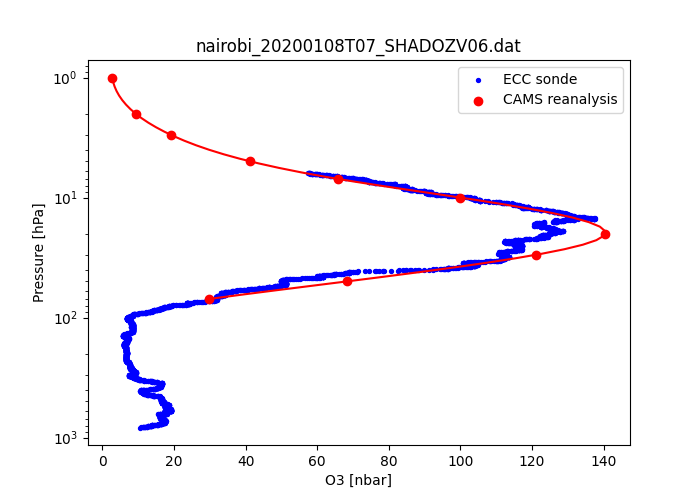

In [4]:
import matplotlib.pyplot as plt

fig = plt.figure(figsize=(7, 5))
plt.scatter(df_ecc['O3_mPa']*10, df_ecc['Press'], s=8, c="b", label='ECC sonde')
plt.scatter(df_cams_month['O3_mPa']*10, df_cams_month['level'], c='red', label='CAMS reanalysis')
plt.plot(df_cams_interpolated['O3_mPa']*10, df_cams_interpolated['Press'], c='red')
plt.yscale('log')
plt.xlabel('O3 [nbar]')
plt.ylabel('Pressure [hPa]')
plt.title(df_ecc['filename'][0])
plt.gca().invert_yaxis()
plt.legend()
plt.show()

In [6]:
import numpy as np

# integrate ecc sonde data
# [Press] = hPa, [O3_mPa] = mPa, [tco_ecc] = DU
tco_ecc = calculate_total_column_ozone(df_ecc)
# tco_ecc = compute_total_column_ozone_from_insitu_profile(df_ecc['Press'], df_ecc['O3_mPa'])

print(tco_ecc)



-172.08083217060226


In [ ]:
# compute residual profile from CAMS reanalysis
burst_pressure = min(df_ecc['Press'])

df_cams_interpolated_residual = df_cams_interpolated.filter(pl.col('Press') <= burst_pressure)
print(df_cams_interpolated_residual)
# Compute the total column ozone in DU
tco_residual = compute_total_column_ozone_from_insitu_profile(df_cams_interpolated_residual['Press'], df_cams_interpolated_residual['O3_mPa'])
print(tco_residual)